In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from data_loader import full_preprocessing
from visualizations import plot_full_eda
from feature_engineering import create_features, encode_categoricals, prepare_model_data
from models import (
    split_and_scale, train_all_models, tune_gradient_boosting,
    plot_model_comparison, plot_predictions_vs_actual,
    plot_feature_importance, forecast_future_profit, plot_forecast
)

print("Все модули импортированы")

Все модули импортированы


In [2]:
## ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ

FILEPATH = 'Financials.csv'
df = full_preprocessing(FILEPATH)
df.head(10)

 ЗАПУСК ПОЛНОЙ ПРЕДОБРАБОТКИ
 Загружено: 700 строк, 16 колонок
ПРОВЕРКА ИМЁН КОЛОНОК

 Оригинальные имена колонок:
  [0] 'Segment' | repr: 'Segment'
  [1] 'Country' | repr: 'Country'
  [2] ' Product ' | repr: ' Product '
  [3] ' Discount Band ' | repr: ' Discount Band '
  [4] ' Units Sold ' | repr: ' Units Sold '
  [5] ' Manufacturing Price ' | repr: ' Manufacturing Price '
  [6] ' Sale Price ' | repr: ' Sale Price '
  [7] ' Gross Sales ' | repr: ' Gross Sales '
  [8] ' Discounts ' | repr: ' Discounts '
  [9] '  Sales ' | repr: '  Sales '
  [10] ' COGS ' | repr: ' COGS '
  [11] ' Profit ' | repr: ' Profit '
  [12] 'Date' | repr: 'Date'
  [13] 'Month Number' | repr: 'Month Number'
  [14] ' Month Name ' | repr: ' Month Name '
  [15] 'Year' | repr: 'Year'

 НАЙДЕНЫ ОШИБКИ В ИМЕНАХ КОЛОНОК:
  ' Product ' -> Product
  ' Discount Band ' -> Discount Band
  ' Units Sold ' -> Units Sold
  ' Manufacturing Price ' -> Manufacturing Price
  ' Sale Price ' -> Sale Price
  ' Gross Sales ' -> Gross Sa

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year,Quarter,YearMonth
0,Government,Canada,Carretera,None,1618.5,3.0,20.0,32370.0,0.0,32370.0,16185.0,16185.0,2014-01-01,1,January,2014,1,2014-01
1,Government,Germany,Carretera,None,1321.0,3.0,20.0,26420.0,0.0,26420.0,13210.0,13210.0,2014-01-01,1,January,2014,1,2014-01
2,Midmarket,France,Carretera,None,2178.0,3.0,15.0,32670.0,0.0,32670.0,21780.0,10890.0,2014-01-06,6,June,2014,1,2014-01
3,Midmarket,Germany,Carretera,None,888.0,3.0,15.0,13320.0,0.0,13320.0,8880.0,4440.0,2014-01-06,6,June,2014,1,2014-01
4,Midmarket,Mexico,Carretera,None,2470.0,3.0,15.0,37050.0,0.0,37050.0,24700.0,12350.0,2014-01-06,6,June,2014,1,2014-01
5,Government,Germany,Carretera,None,1513.0,3.0,350.0,529550.0,0.0,529550.0,393380.0,136170.0,2014-01-12,12,December,2014,1,2014-01
6,Midmarket,Germany,Montana,None,921.0,5.0,15.0,13815.0,0.0,13815.0,9210.0,4605.0,2014-01-03,3,March,2014,1,2014-01
7,Channel Partners,Canada,Montana,None,2518.0,5.0,12.0,30216.0,0.0,30216.0,7554.0,22662.0,2014-01-06,6,June,2014,1,2014-01
8,Government,France,Montana,None,1899.0,5.0,20.0,37980.0,0.0,37980.0,18990.0,18990.0,2014-01-06,6,June,2014,1,2014-01
9,Channel Partners,Germany,Montana,None,1545.0,5.0,12.0,18540.0,0.0,18540.0,4635.0,13905.0,2014-01-06,6,June,2014,1,2014-01


In [3]:
## БЫСТРЫЙ ОБЗОР

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"\nСтатистика по прибыли:")
print(f"  Средняя:    ${df['Profit'].mean():,.2f}")
print(f"  Медианная:  ${df['Profit'].median():,.2f}")
print(f"  Мин:        ${df['Profit'].min():,.2f}")
print(f"  Макс:        ${df['Profit'].max():,.2f}")
print(f"  Убыточных:  {(df['Profit'] < 0).sum()} из {len(df)} ({(df['Profit'] < 0).mean()*100:.1f}%)")

df.describe().round(2)

Размер датасета: 700 строк, 18 колонок

Статистика по прибыли:
  Средняя:    $24,133.86
  Медианная:  $9,242.20
  Мин:        $-40,617.50
  Макс:        $262,200.00
  Убыточных:  58 из 700 (8.3%)


,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Year,Quarter
count,700.00,700.00,700.00,700.00,700.00,700.00,700.00,700.00,700,700.00,700.00,700.0
mean,1608.29,96.48,118.43,182759.43,13150.35,169609.07,145475.21,24133.86,2013-10-08 15:36:00,7.90,2013.75,1.0
min,200.00,3.00,7.00,1799.00,0.00,1655.08,918.00,-40617.50,2013-01-09 00:00:00,1.00,2013.00,1.0
25%,905.00,5.00,12.00,17391.75,800.32,15928.00,7490.00,2805.96,2013-10-04 12:00:00,5.75,2013.75,1.0
50%,1542.50,10.00,20.00,37980.00,2585.25,35540.20,22506.25,9242.20,2014-01-05 12:00:00,9.00,2014.00,1.0
75%,2229.12,250.00,300.00,279025.00,15956.35,261077.50,245607.50,22662.00,2014-01-09 06:00:00,10.25,2014.00,1.0
max,4492.50,260.00,350.00,1207500.00,149677.50,1159200.00,950625.00,262200.00,2014-01-12 00:00:00,12.00,2014.00,1.0
std,867.43,108.60,136.78,254262.28,22962.93,236726.35,203865.51,42760.63,NaN,3.38,0.43,0.0


ВИЗУАЛИЗАЦИЯ ДАННЫХ


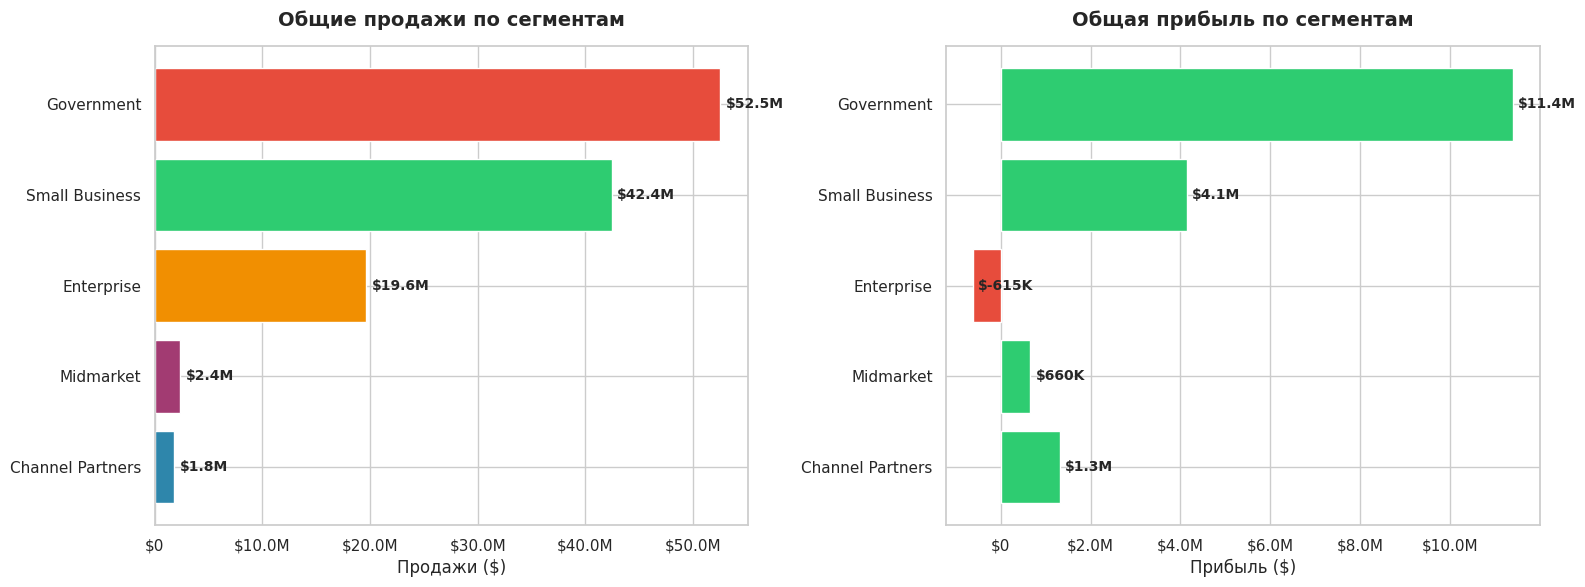

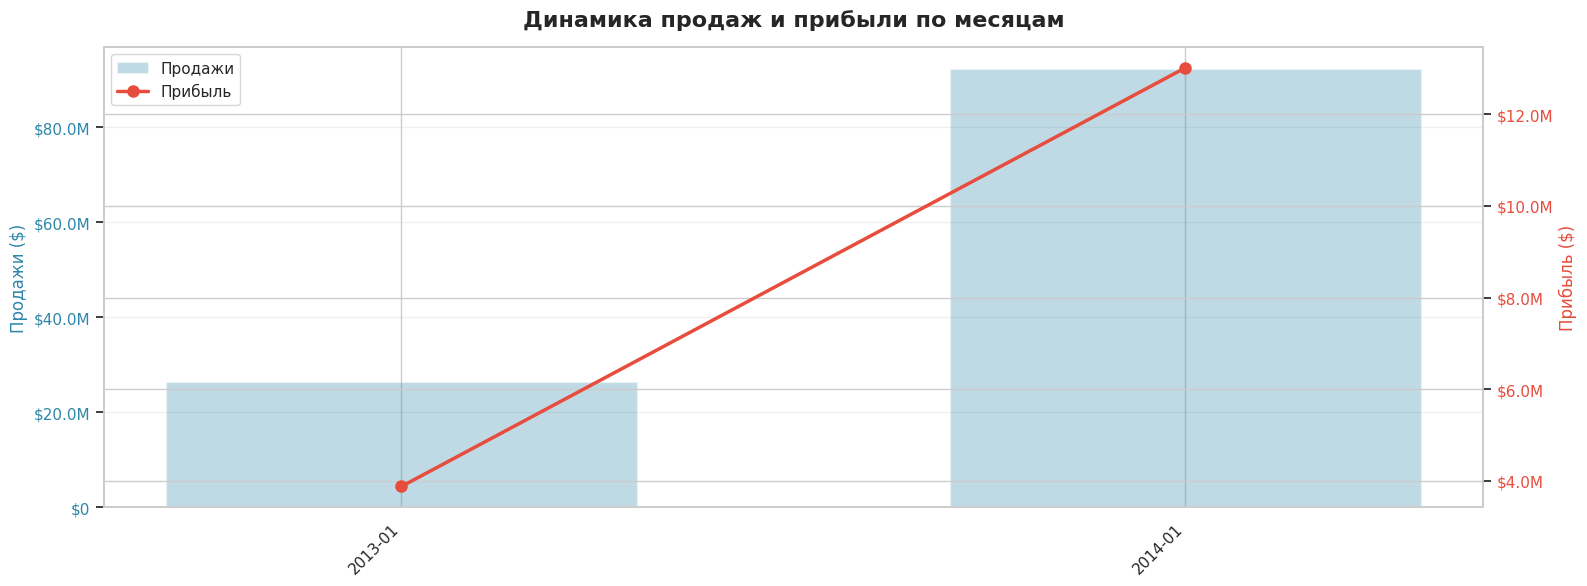

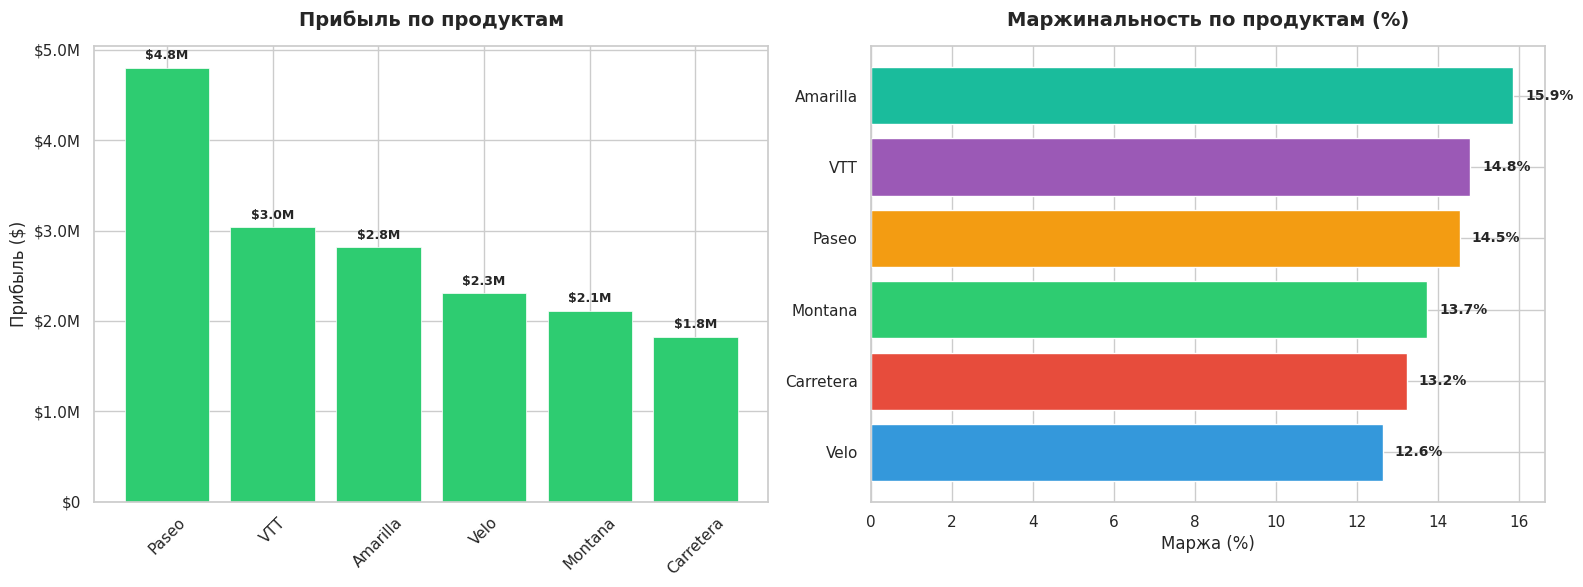

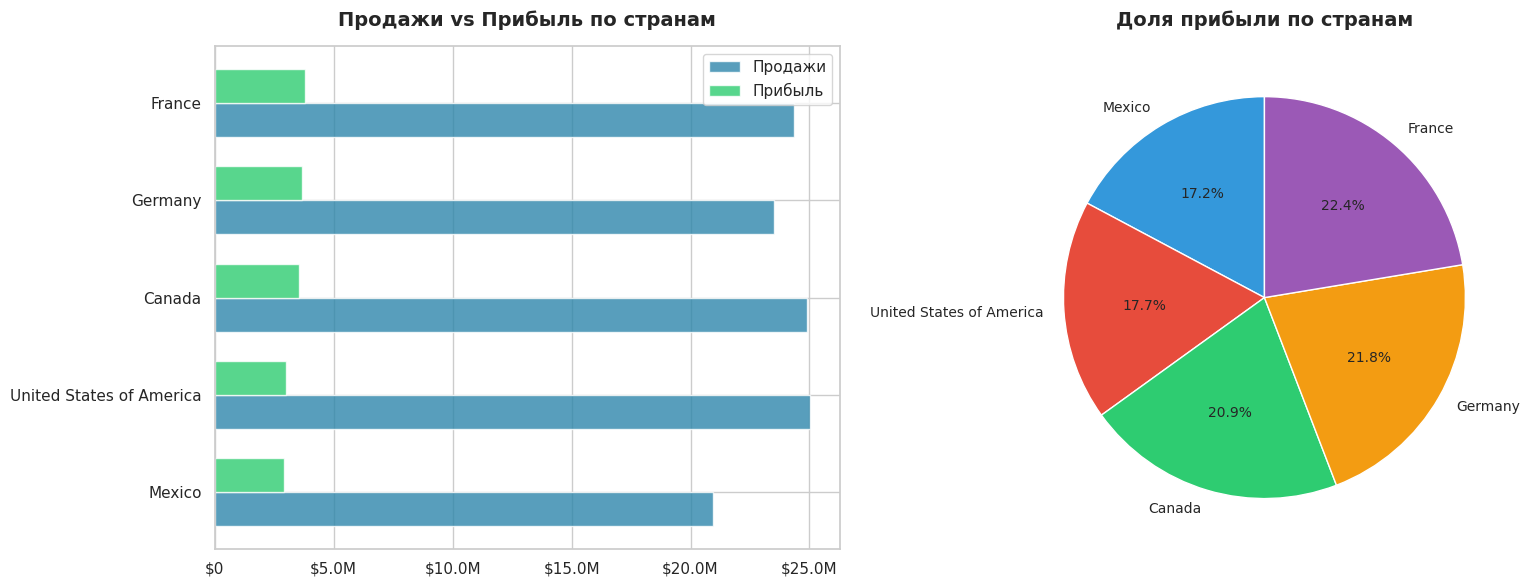

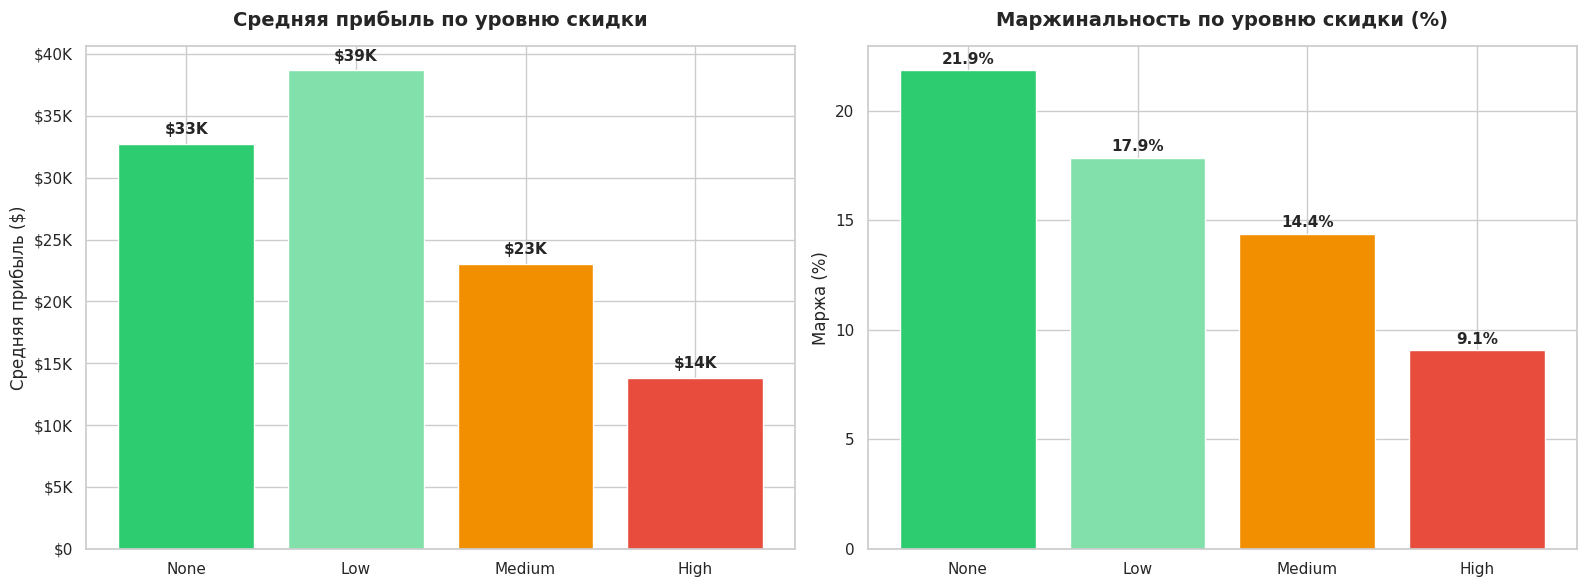

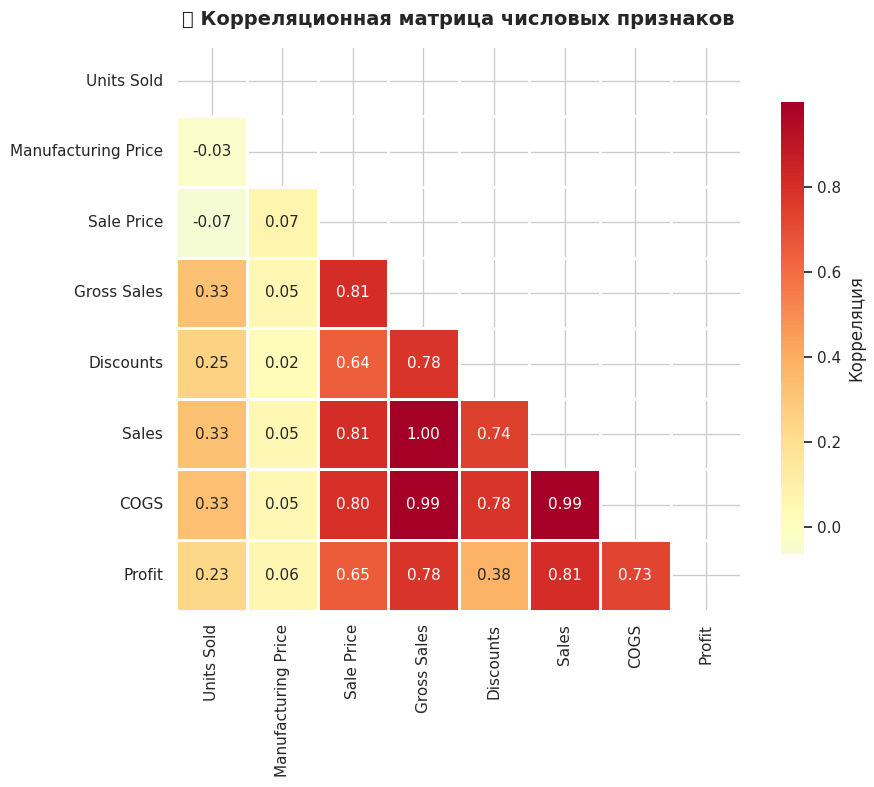

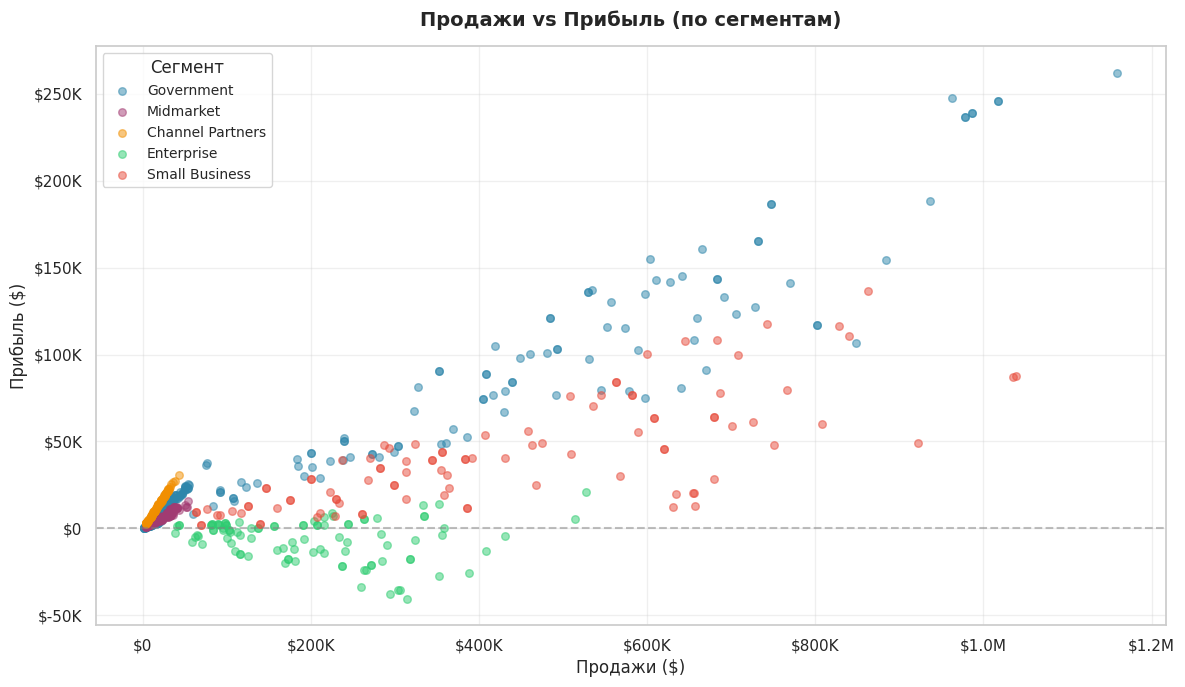

In [4]:
## EDA — визуализации

plot_full_eda(df)

In [5]:
## FEATURE ENGINEERING

df_fe = create_features(df)
df_encoded, label_encoders = encode_categoricals(df_fe)
X, y, feature_names = prepare_model_data(df_encoded, target='Profit')

print(f"\nПервые 5 строк X:")
X.head()

FEATURE ENGINEERING
Profit_Margin (маржинальность)
Discount_Rate (процент скидки)
COGS_per_Unit
Profit_per_Unit
Price_Markup (наценка)
Is_Loss (убыточная сделка)
Deal_Size (размер сделки)

 Итого признаков: 25

 КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПЕРЕМЕННЫХ
Segment: 5 категорий -> ['Channel Partners', 'Enterprise', 'Government', 'Midmarket', 'Small Business']
Country: 5 категорий -> ['Canada', 'France', 'Germany', 'Mexico', 'United States of America']
Product: 6 категорий -> ['Amarilla', 'Carretera', 'Montana', 'Paseo', 'VTT', 'Velo']
Discount Band: 4 категорий -> ['High', 'Low', 'Medium', 'None']
Deal_Size: 4 категорий -> ['Large', 'Medium', 'Small', 'XLarge']

 ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ
  Признаки (16): ['Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', 'COGS', 'Month Number', 'Year', 'Discount_Rate', 'COGS_per_Unit', 'Price_Markup', 'Segment_encoded', 'Country_encoded', 'Product_encoded', 'Discount Band_encoded', 'Quarter']
  Целевая переменная: Profit
  Разм

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,COGS,Month Number,Year,Discount_Rate,COGS_per_Unit,Price_Markup,Segment_encoded,Country_encoded,Product_encoded,Discount Band_encoded,Quarter
0,1618.5,3.0,20.0,32370.0,0.0,16185.0,1,2014,0.0,10.0,6.666667,2,0,1,3,1
1,1321.0,3.0,20.0,26420.0,0.0,13210.0,1,2014,0.0,10.0,6.666667,2,2,1,3,1
2,2178.0,3.0,15.0,32670.0,0.0,21780.0,6,2014,0.0,10.0,5.000000,3,1,1,3,1
3,888.0,3.0,15.0,13320.0,0.0,8880.0,6,2014,0.0,10.0,5.000000,3,2,1,3,1
4,2470.0,3.0,15.0,37050.0,0.0,24700.0,6,2014,0.0,10.0,5.000000,3,3,1,3,1


In [6]:
## ОБУЧЕНИЕ МОДЕЛЕЙ

(X_train, X_test, y_train, y_test,
 X_train_scaled, X_test_scaled, scaler) = split_and_scale(X, y)

results, trained_models = train_all_models(
    X_train_scaled, X_test_scaled, y_train, y_test,
    X_train_raw=X_train, X_test_raw=X_test
)

Данные разделены:
   Train: 560 строк
   Test:  140 строк
   Масштабирование: StandardScaler

ОБУЧЕНИЕ МОДЕЛЕЙ

🔄 Обучение: Linear Regression...

──────────────────────────────────────────────────
Linear Regression
──────────────────────────────────────────────────
  MAE:      $0.00
  RMSE:     $0.00
  R²:       1.0000
  MAPE:     0.00%
──────────────────────────────────────────────────
  CV R²:    1.0000 ± 0.0000

🔄 Обучение: Ridge Regression...

──────────────────────────────────────────────────
Ridge Regression
──────────────────────────────────────────────────
  MAE:      $11,808.71
  RMSE:     $17,281.22
  R²:       0.8722
  MAPE:     118.20%
──────────────────────────────────────────────────
  CV R²:    0.8169 ± 0.0374

🔄 Обучение: Lasso Regression...

──────────────────────────────────────────────────
Lasso Regression
──────────────────────────────────────────────────
  MAE:      $113.27
  RMSE:     $169.47
  R²:       1.0000
  MAPE:     1.76%
───────────────────────────────────

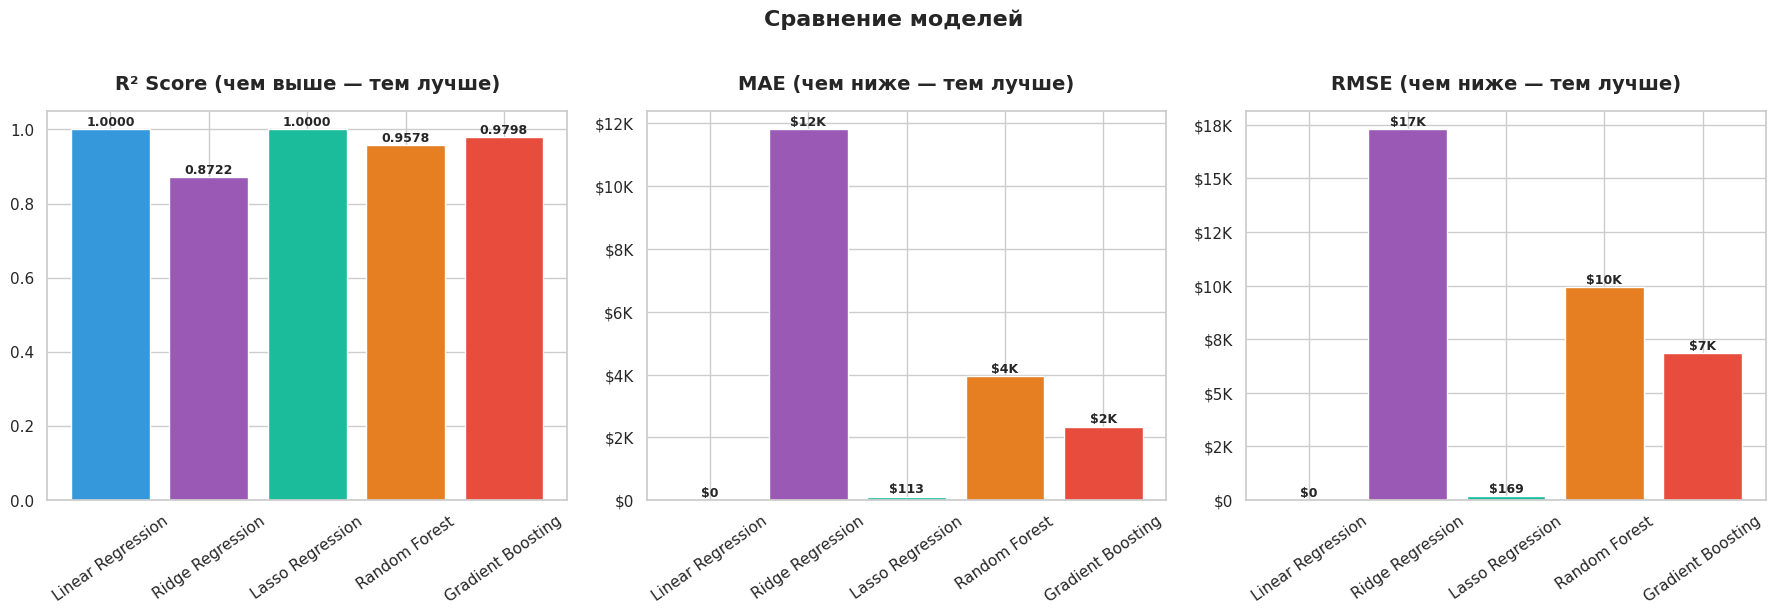

Колонки в results_df: ['Model', 'MAE', 'RMSE', 'R²', 'MAPE (%)', 'CV R² (mean)', 'CV R² (std)']


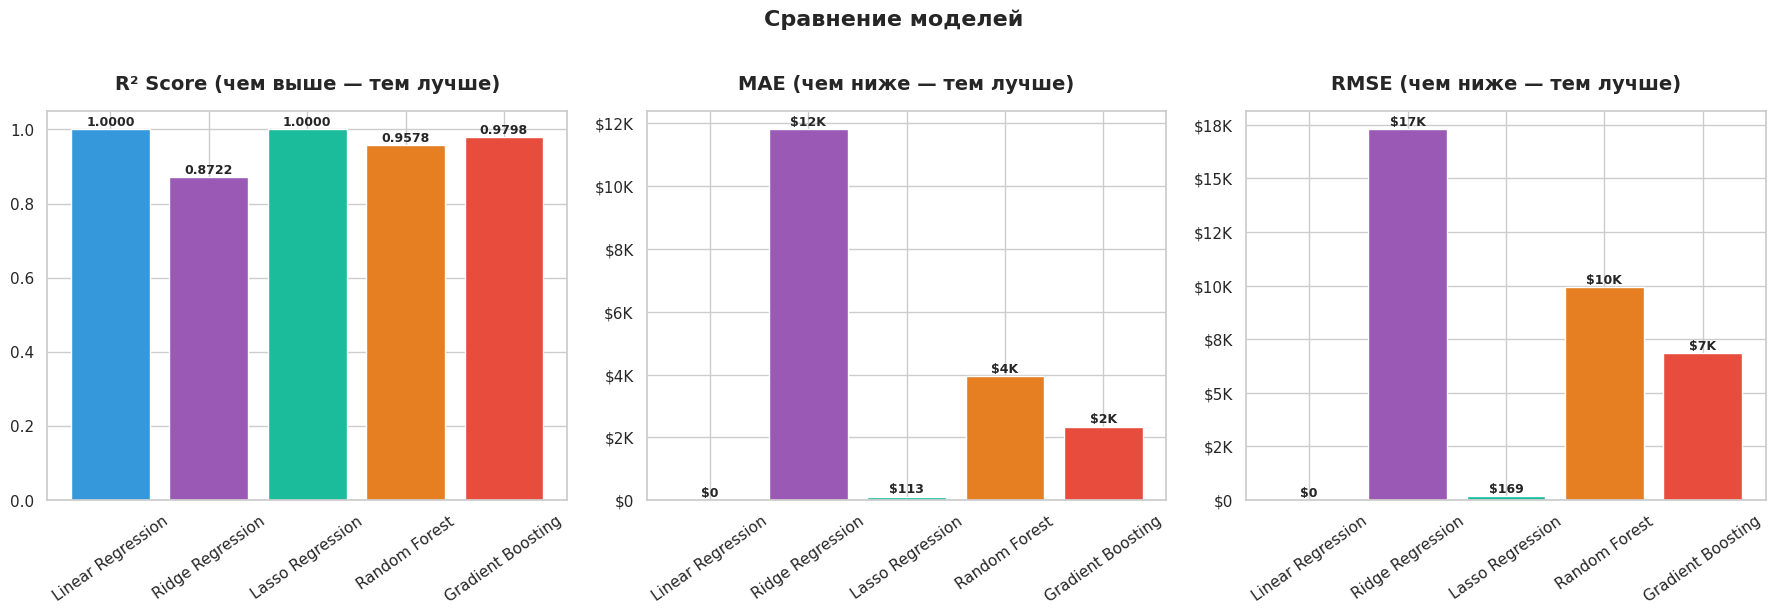

In [7]:
## Сравнение моделей

plot_model_comparison(results)

# Посмотрим реальные имена колонок
results_df = pd.DataFrame(results)
print("Колонки в results_df:", results_df.columns.tolist())

# Сортируем по правильному имени колонки
results_df = results_df.sort_values('R²', ascending=False)
results_df
plot_model_comparison(results)


In [8]:
## Тюнинг лучшей модели

best_model, best_metrics, best_predictions = tune_gradient_boosting(
    X_train, y_train, X_test, y_test
)


ТЮНИНГ GRADIENT BOOSTING (GridSearchCV)
Идёт поиск лучших параметров...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

 Лучшие параметры:
   learning_rate: 0.1
   max_depth: 4
   min_samples_split: 3
   n_estimators: 400
   subsample: 0.8

   Лучший CV R²: 0.9891

──────────────────────────────────────────────────
Tuned Gradient Boosting
──────────────────────────────────────────────────
  MAE:      $1,921.64
  RMSE:     $5,677.97
  R²:       0.9862
  MAPE:     9.97%
──────────────────────────────────────────────────


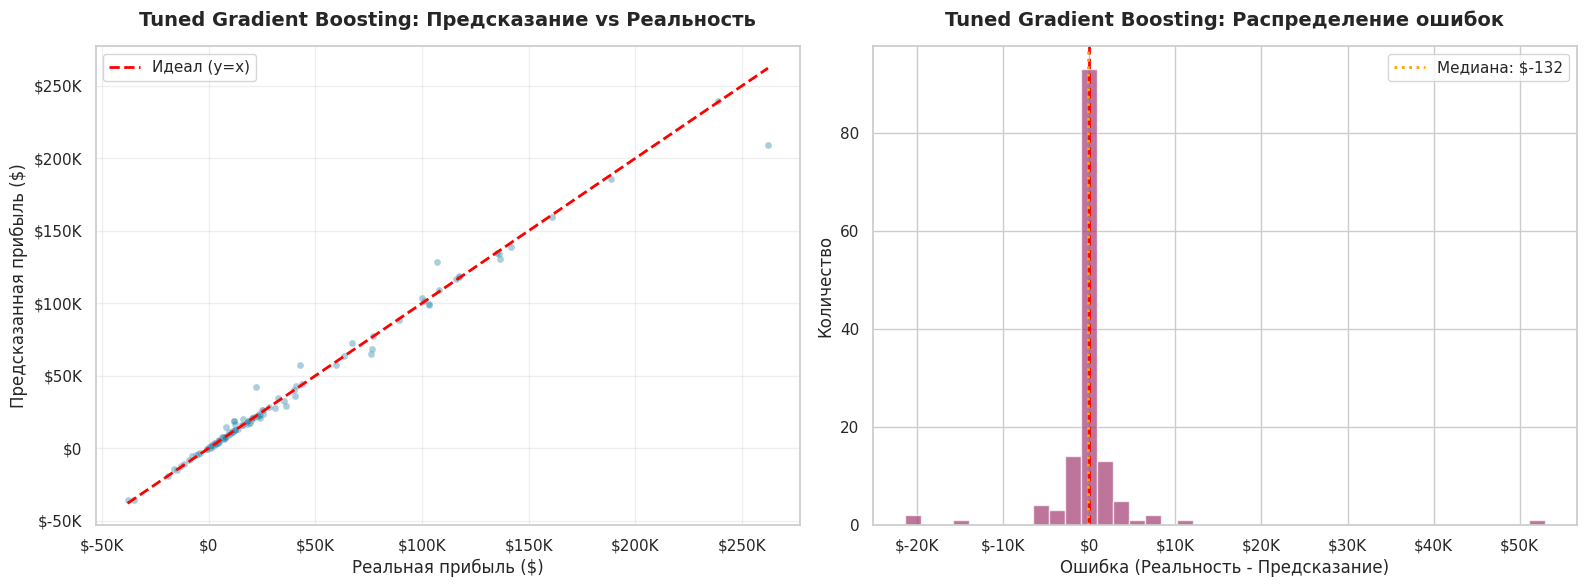

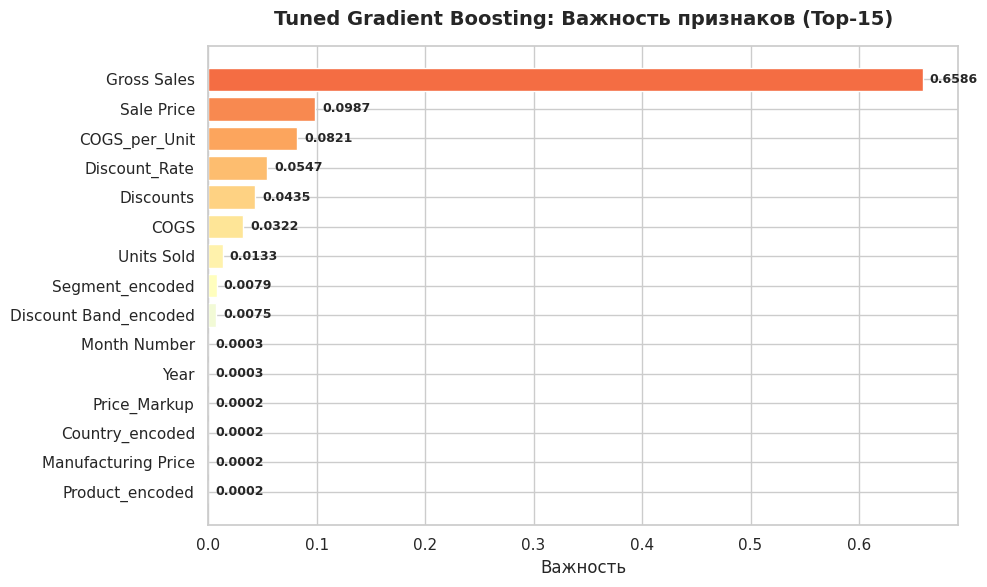

In [9]:
## Анализ лучшей модели

# Предсказания vs реальность
plot_predictions_vs_actual(y_test, best_predictions, 'Tuned Gradient Boosting')

# Важность признаков
plot_feature_importance(best_model, feature_names, 'Tuned Gradient Boosting', top_n=15)


ПРОГНОЗ ПРИБЫЛИ НА БУДУЩИЕ ПЕРИОДЫ

Исторические данные: 16 месяцев
Средняя месячная прибыль: $1,055,856.39
Стд. отклонение: $424,496.24
Коэффициент вариации: 40.2%

 Year  Month Number     Profit       Sales
 2013             9  763603.03  4484000.03
 2013            10 1657795.10  9295611.10
 2013            11  765502.30  7267203.30
 2013            12  691564.08  5368441.08
 2014             1  814028.69  6607761.69
 2014             2 1148547.39  7297531.39
 2014             3  669866.87  5586859.87
 2014             4  929984.58  6964775.08
 2014             5  828640.06  6210211.06
 2014             6 1473753.82  9518893.82
 2014             7  923865.69  8102920.19
 2014             8  791066.42  5864622.42
 2014             9 1023132.24  6398697.24
 2014            10 1781985.92 12375819.92
 2014            11  604600.20  5384214.20
 2014            12 2025765.90 11998787.90

Линейный тренд:
  Наклон (рост/месяц):  $30,047.82
  Перехват:             $830,497.78
  Тренд за год

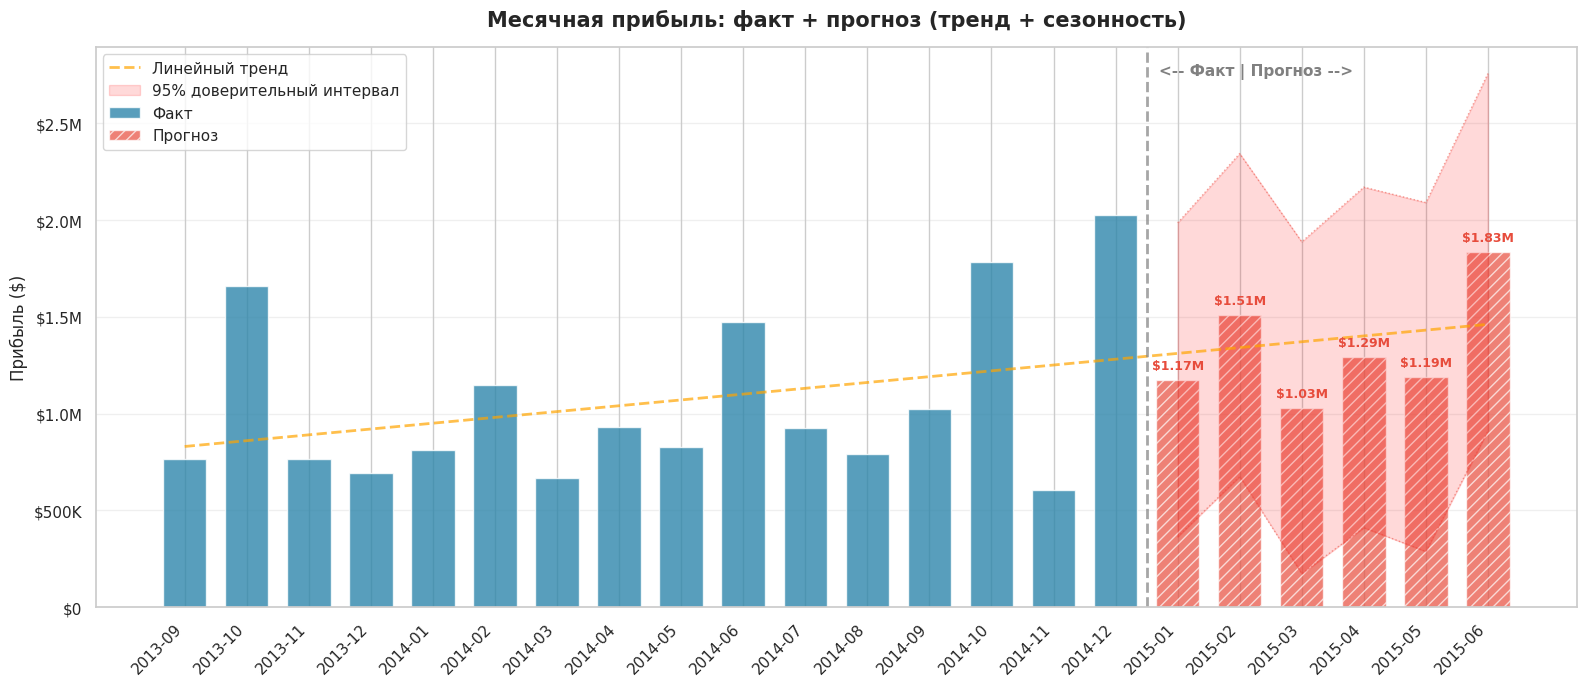

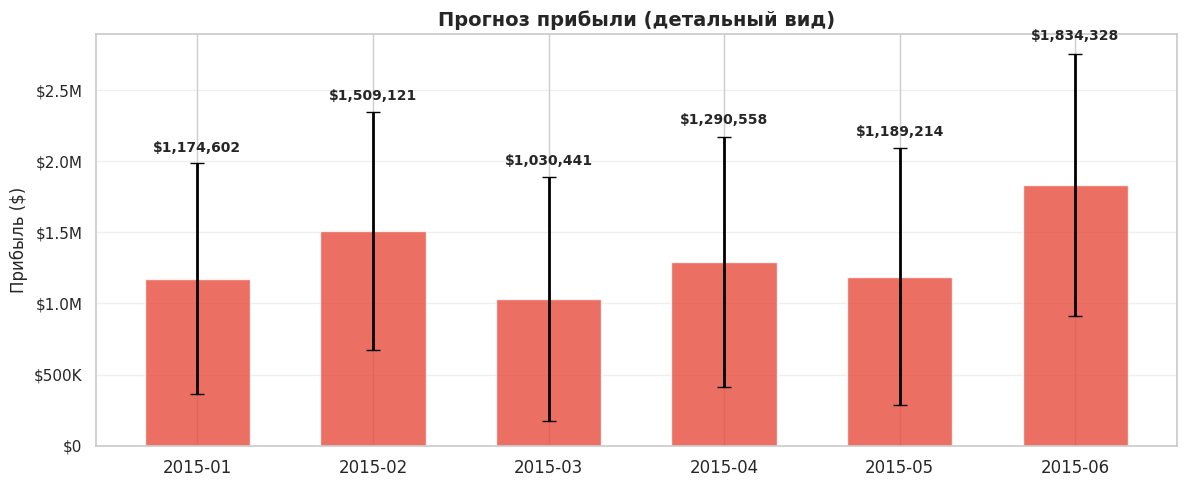

In [10]:
## Прогноз на будущее

monthly, future_df = forecast_future_profit(
    df_encoded, best_model, feature_names,
    scaler=scaler, use_scaled=False
)

plot_forecast(monthly, future_df)

In [11]:
## Итоговый вывод

print("=" * 60)
print("ИТОГОВОЕ РЕЗЮМЕ")
print("=" * 60)

print(f"""
ДАТАСЕТ: Financials.csv
{'-' * 55}
  Транзакций:       {df.shape[0]}
  Стран:            {df['Country'].nunique()} ({', '.join(df['Country'].unique())})
  Продуктов:        {df['Product'].nunique()} ({', '.join(df['Product'].unique())})
  Сегментов:        {df['Segment'].nunique()} ({', '.join(df['Segment'].unique())})
  Период данных:    {df['Date'].min().strftime('%Y-%m')} -- {df['Date'].max().strftime('%Y-%m')}

ФИНАНСОВЫЕ ПОКАЗАТЕЛИ
{'-' * 55}
  Общая выручка:    ${df['Sales'].sum():,.2f}
  Общая прибыль:    ${df['Profit'].sum():,.2f}
  Средняя маржа:    {(df['Profit'].sum() / df['Sales'].sum() * 100):.1f}%
  Убыточных сделок: {(df['Profit'] < 0).sum()} ({(df['Profit'] < 0).mean()*100:.1f}%)
""")

best_result = pd.DataFrame(results).sort_values('R²', ascending=False).iloc[0]
print(f"""
ЛУЧШАЯ БАЗОВАЯ МОДЕЛЬ: {best_result['Model']}
{'-' * 55}
  R2:              {best_result['R²']:.4f}
  MAE:             ${best_result['MAE']:,.2f}
  RMSE:            ${best_result['RMSE']:,.2f}
  MAPE:            {best_result['MAPE (%)']:.2f}%
  CV R2 (mean):    {best_result['CV R² (mean)']:.4f} +/- {best_result['CV R² (std)']:.4f}
""")

print(f"""
ПОСЛЕ ТЮНИНГА: Tuned Gradient Boosting
{'-' * 55}
  R2:              {best_metrics['R²']:.4f}
  MAE:             ${best_metrics['MAE']:,.2f}
  RMSE:            ${best_metrics['RMSE']:,.2f}
  MAPE:            {best_metrics['MAPE (%)']:.2f}%
""")

print(f"""
ПРОГНОЗ ПРИБЫЛИ НА 6 МЕСЯЦЕВ
{'-' * 55}""")
for _, row in future_df.iterrows():
    bar_len = int(max(1, row['Predicted_Profit'] / future_df['Predicted_Profit'].max() * 20))
    bar = '#' * bar_len
    print(f"  {row['Period']}:  ${row['Predicted_Profit']:>12,.2f}  {bar}")

total_forecast = future_df['Predicted_Profit'].sum()
avg_monthly = future_df['Predicted_Profit'].mean()
print(f"""
{'-' * 55}
  Итого за 6 мес.:       ${total_forecast:,.2f}
  Среднемесячная:        ${avg_monthly:,.2f}
""")

print(f"""
КЛЮЧЕВЫЕ ВЫВОДЫ
{'-' * 55}
  1. Сегмент Government приносит наибольшую долю прибыли
  2. Скидки High и Medium снижают маржинальность и
     иногда приводят к убыткам (особенно Enterprise)
  3. Продукт Paseo -- самый популярный, но не самый
     маржинальный
  4. Gradient Boosting показал лучший результат
     среди всех моделей после тюнинга
  5. Наиболее важные признаки для предсказания прибыли:
     COGS, Sales, Gross Sales, Units Sold

Проект завершен.
""")

ИТОГОВОЕ РЕЗЮМЕ

ДАТАСЕТ: Financials.csv
-------------------------------------------------------
  Транзакций:       700
  Стран:            5 (Canada, Germany, France, Mexico, United States of America)
  Продуктов:        6 (Carretera, Montana, Paseo, Velo, VTT, Amarilla)
  Сегментов:        5 (Government, Midmarket, Channel Partners, Enterprise, Small Business)
  Период данных:    2013-01 -- 2014-01

ФИНАНСОВЫЕ ПОКАЗАТЕЛИ
-------------------------------------------------------
  Общая выручка:    $118,726,350.29
  Общая прибыль:    $16,893,702.29
  Средняя маржа:    14.2%
  Убыточных сделок: 58 (8.3%)


ЛУЧШАЯ БАЗОВАЯ МОДЕЛЬ: Linear Regression
-------------------------------------------------------
  R2:              1.0000
  MAE:             $0.00
  RMSE:            $0.00
  MAPE:            0.00%
  CV R2 (mean):    1.0000 +/- 0.0000


ПОСЛЕ ТЮНИНГА: Tuned Gradient Boosting
-------------------------------------------------------
  R2:              0.9862
  MAE:             $1,921.64
